In [1]:
import pandas as pd

df = pd.read_csv("spotify_songs.csv")
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [2]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [3]:
df.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='str')

In [4]:
# Show number of rows and columns
print("Dataset shape:", df.shape)

# Show general information about the dataset
df.info()

Dataset shape: (32833, 23)
<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int

In [5]:
# Create a working copy
spotify = df.copy()

# Drop rows with missing important values
spotify = spotify.dropna(subset=[
    'track_name',
    'track_artist',
    'playlist_genre'
])

# Remove duplicates
spotify = spotify.drop_duplicates()

print("Cleaned shape:", spotify.shape)

Cleaned shape: (32828, 23)


In [6]:
# Convert release date to datetime
spotify['track_album_release_date'] = pd.to_datetime(
    spotify['track_album_release_date'], errors='coerce'
)

# Extract year
spotify['year'] = spotify['track_album_release_date'].dt.year

# Drop rows where year is missing
spotify = spotify.dropna(subset=['year'])

# Convert year to integer
spotify['year'] = spotify['year'].astype(int)

spotify.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,2019
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2019
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2019
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2019
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,2019


In [7]:
genre_df = spotify['playlist_genre'].value_counts().reset_index()

genre_df.columns = ['genre', 'song_count']

genre_df.head()

,genre,song_count
0,edm,5969
1,rap,5468
2,pop,5303
3,r&b,5094
4,latin,4961


In [8]:
year_df = spotify['year'].value_counts().sort_index().reset_index()

year_df.columns = ['year', 'song_count']

year_df.head()

,year,song_count
0,1957,1
1,1958,1
2,1961,1
3,1963,4
4,1964,8


In [9]:
year_df.tail()

,year,song_count
56,2016,2114
57,2017,2424
58,2018,3312
59,2019,9079
60,2020,785


In [10]:
artist_df = spotify['track_artist'].value_counts().head(10).reset_index()

artist_df.columns = ['artist', 'song_count']

artist_df.head()

,artist,song_count
0,Martin Garrix,161
1,Queen,133
2,The Chainsmokers,123
3,David Guetta,109
4,Drake,100


In [11]:
spotify = df.copy()

In [12]:
# Save the fully cleaned dataset
spotify.to_csv("spotify_cleaned.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [13]:
# Convert to datetime
df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], errors='coerce')

# Extract year
df['year'] = df['track_album_release_date'].dt.year

# Drop rows where year is missing
df = df.dropna(subset=['year'])

# Convert year to integer
df['year'] = df['year'].astype(int)

# Save again
df.to_csv("spotify_cleaned.csv", index=False)

print("Final cleaned dataset saved!")

Final cleaned dataset saved!


In [14]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


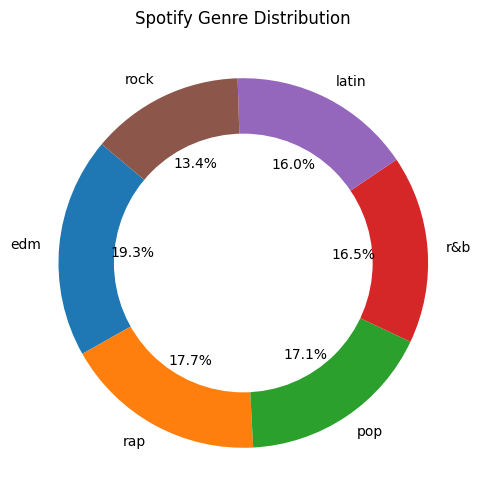

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("spotify_cleaned.csv")

# Count genres
genre_counts = df['playlist_genre'].value_counts()

# Keep top 6 for clean chart
genre_counts = genre_counts.head(6)

# Create donut chart
plt.figure(figsize=(6,6))
plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

# Create donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

# Title
plt.title("Spotify Genre Distribution")

plt.show()

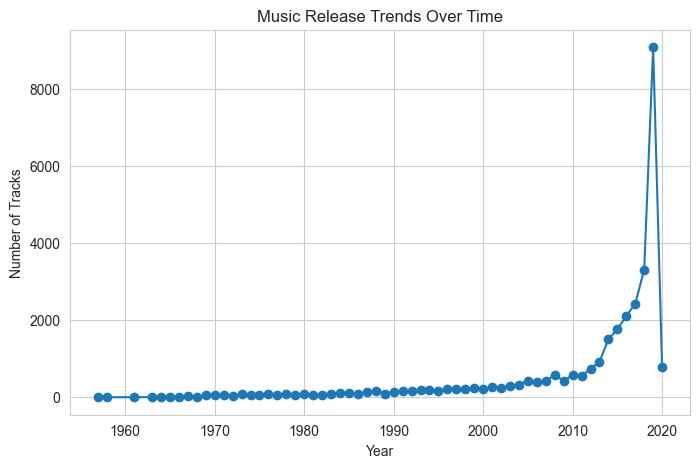

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("spotify_cleaned.csv")

# Count songs per year
year_counts = df['year'].value_counts().sort_index()

# Plot line chart
plt.figure(figsize=(8,5))
plt.plot(year_counts.index, year_counts.values, marker='o')

# Labels and title
plt.xlabel("Year")
plt.ylabel("Number of Tracks")
plt.title("Music Release Trends Over Time")

plt.grid(True)
plt.show()

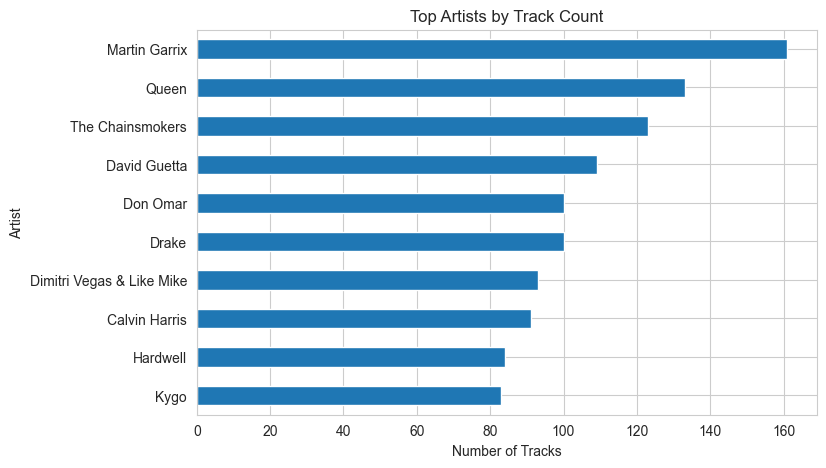

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("spotify_cleaned.csv")

# Top 10 artists
artist_counts = df['track_artist'].value_counts().head(10)

# Plot horizontal bar chart
plt.figure(figsize=(8,5))
artist_counts.sort_values().plot(kind='barh')

# Labels and title
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")
plt.title("Top Artists by Track Count")

plt.show()

## Genre Distribution
EDM, Pop, and Rap dominate Spotify playlists, indicating a strong preference for mainstream and high-energy music.

---

## Music Release Trends
Music releases increased significantly after 2015, reflecting the growth of streaming platforms and digital distribution.

---

## Top Artists
A small group of artists contributes a large share of tracks, showing concentration of content among top creators.

---

## Summary
Spotify content is driven by dominant genres, rapid growth in releases, and a few high-output artists.